# Exercise: Discrete-Time Model of Political Opinion Dynamics

## Setup

Three ideologies share 100% of public opinion:
- $p_r$ = Republican popularity &nbsp; ($0 \leq p_r \leq 1$)
- $p_d$ = Democrat popularity &nbsp;&nbsp;&nbsp; ($0 \leq p_d \leq 1$)
- $p_i = 1 - p_r - p_d$ = Independent popularity

## Building the Equations

At each poll, people switch from option X to option Y at a rate proportional to $\max(p_Y - p_X,\, 0)$ — you only switch toward something more popular than where you are. The fraction of X-people who actually switch = (fraction in X) $\times$ (rate), giving six flows:

| Flow | Formula |
|:----:|:-------:|
| $R \to D$ | $p_r \cdot \max(p_d - p_r,\, 0)$ |
| $R \to I$ | $p_r \cdot \max(p_i - p_r,\, 0)$ |
| $D \to R$ | $p_d \cdot \max(p_r - p_d,\, 0)$ |
| $D \to I$ | $p_d \cdot \max(p_i - p_d,\, 0)$ |
| $I \to R$ | $p_i \cdot \max(p_r - p_i,\, 0)$ |
| $I \to D$ | $p_i \cdot \max(p_d - p_i,\, 0)$ |

Collecting gains and losses for each variable (following the same **simultaneous-update** structure as Code 4.13):

$$p_r^{(t+1)} = p_r^{(t)} + \underbrace{(D\to R) + (I\to R)}_{\text{gain}} - \underbrace{(R\to D) - (R\to I)}_{\text{loss}}$$

$$p_d^{(t+1)} = p_d^{(t)} + (R\to D) + (I\to D) - (D\to R) - (D\to I)$$

$$p_i = 1 - p_r - p_d \quad \text{(derived, not modeled separately)}$$

Conservation $p_r + p_d + p_i = 1$ is preserved automatically since the six flows cancel in pairs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

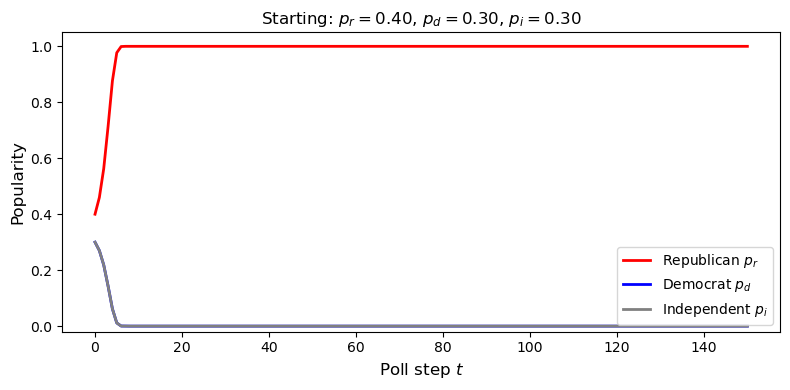

Final state:  pr=1.0000,  pd=0.0000,  pi=0.0000


In [2]:
# ── The discrete-time model (revised from Code 4.13 structure) ────────────────
# Key idea: compute ALL next-step values before updating any variable.

def step(pr, pd):
    """One discrete time step. Returns (next_pr, next_pd)."""
    pi = 1 - pr - pd

    # Six switching flows
    flow_rd = pr * max(pd - pr, 0)    # R → D
    flow_ri = pr * max(pi - pr, 0)    # R → I
    flow_dr = pd * max(pr - pd, 0)    # D → R
    flow_di = pd * max(pi - pd, 0)    # D → I
    flow_ir = pi * max(pr - pi, 0)    # I → R
    flow_id = pi * max(pd - pi, 0)    # I → D

    # Simultaneous update — like Code 4.13, we store next values first
    next_pr = pr + (-flow_rd - flow_ri + flow_dr + flow_ir)
    next_pd = pd + (-flow_dr - flow_di + flow_rd + flow_id)

    return next_pr, next_pd


def simulate(pr0, pd0, T=150):
    """Run T steps from initial (pr0, pd0). Returns history arrays."""
    pr, pd = pr0, pd0
    history = [(pr, pd, 1 - pr - pd)]
    for _ in range(T):
        pr, pd = step(pr, pd)
        history.append((pr, pd, 1 - pr - pd))
    return np.array(history)   # shape (T+1, 3) → columns: pr, pd, pi


# ── Single simulation: R slightly ahead ──────────────────────────────────────
hist = simulate(0.40, 0.30)   # pr=0.40, pd=0.30, pi=0.30

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist[:, 0], color='red',   lw=2, label='Republican $p_r$')
ax.plot(hist[:, 1], color='blue',  lw=2, label='Democrat $p_d$')
ax.plot(hist[:, 2], color='gray',  lw=2, label='Independent $p_i$')
ax.set_xlabel('Poll step $t$', fontsize=12)
ax.set_ylabel('Popularity', fontsize=12)
ax.set_title('Starting: $p_r=0.40$, $p_d=0.30$, $p_i=0.30$', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

print(f"Final state:  pr={hist[-1,0]:.4f},  pd={hist[-1,1]:.4f},  pi={hist[-1,2]:.4f}")

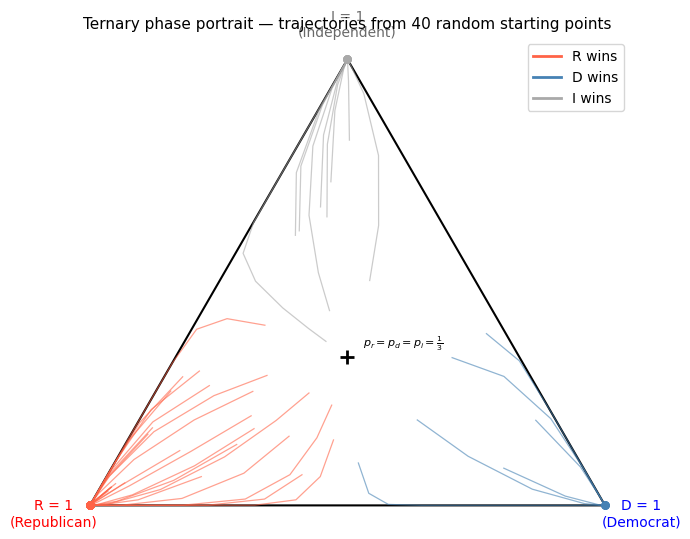

In [3]:
# ── Multiple initial conditions: ternary phase portrait ───────────────────────
# A ternary plot shows all three variables at once. The equilateral triangle
# has vertices: R=1 (bottom-left), D=1 (bottom-right), I=1 (top).
# Each point inside the triangle is one possible state of the system.

def to_xy(pr, pd):
    """Convert (pr, pd) → 2D ternary coordinates."""
    pi = 1 - pr - pd
    x  = pd + pi / 2          # (1 - pr + pd) / 2  -- same thing
    y  = pi * np.sqrt(3) / 2
    return x, y

# Draw the triangle
fig, ax = plt.subplots(figsize=(7, 6.5))
verts = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])
ax.plot(verts[:, 0], verts[:, 1], 'k-', lw=1.5)

# Vertex labels
ax.text(-0.07,  -0.04, 'R = 1\n(Republican)', ha='center', fontsize=10, color='red')
ax.text( 1.07,  -0.04, 'D = 1\n(Democrat)',   ha='center', fontsize=10, color='blue')
ax.text( 0.50,   0.91, 'I = 1\n(Independent)', ha='center', fontsize=10, color='dimgray')

# Mark the equal-split center
cx, cy = to_xy(1/3, 1/3)
ax.plot(cx, cy, 'k+', ms=10, mew=2, zorder=6)
ax.text(cx + 0.03, cy + 0.02, '$p_r=p_d=p_i=\\frac{1}{3}$', fontsize=8)

# Simulate from a grid of initial conditions and plot trajectories
np.random.seed(0)
n_traj = 40
ics = []
while len(ics) < n_traj:
    pr0 = np.random.uniform(0.02, 0.96)
    pd0 = np.random.uniform(0.02, 0.96 - pr0)
    ics.append((pr0, pd0))

for pr0, pd0 in ics:
    hist = simulate(pr0, pd0, T=200)
    xs, ys = to_xy(hist[:, 0], hist[:, 1])

    # Color by winner
    final = hist[-1]
    winner = np.argmax(final)
    col = ['tomato', 'steelblue', 'darkgray'][winner]

    ax.plot(xs, ys, color=col, lw=0.9, alpha=0.6)
    ax.plot(xs[-1], ys[-1], 'o', color=col, ms=5, zorder=5)

legend_elems = [
    Line2D([0],[0], color='tomato',    lw=2, label='R wins'),
    Line2D([0],[0], color='steelblue', lw=2, label='D wins'),
    Line2D([0],[0], color='darkgray',  lw=2, label='I wins'),
]
ax.legend(handles=legend_elems, fontsize=10, loc='upper right')
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Ternary phase portrait — trajectories from 40 random starting points',
             fontsize=11)
plt.tight_layout()
plt.show()

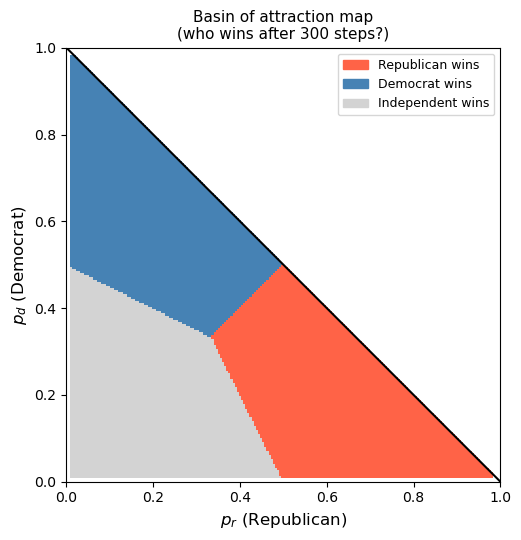

In [4]:
# ── Basin-of-attraction map ───────────────────────────────────────────────────
# For every possible starting state, run 300 steps and record who wins.
# This shows the three basins of attraction clearly.

# Vectorised step for efficiency
def step_vec(pr, pd):
    pi = 1 - pr - pd
    rd = pr * np.maximum(pd - pr, 0)
    ri = pr * np.maximum(pi - pr, 0)
    dr = pd * np.maximum(pr - pd, 0)
    di = pd * np.maximum(pi - pd, 0)
    ir = pi * np.maximum(pr - pi, 0)
    id_ = pi * np.maximum(pd - pi, 0)
    return pr + (-rd - ri + dr + ir), pd + (-dr - di + rd + id_)

from matplotlib.colors import ListedColormap, BoundaryNorm

res = 200
pr_vals = np.linspace(0.01, 0.98, res)
pd_vals = np.linspace(0.01, 0.98, res)
PR, PD = np.meshgrid(pr_vals, pd_vals)

# Only simulate inside the valid simplex (pr + pd <= 1)
valid = PR + PD <= 1.0
pr_run = np.where(valid, PR, 0.0)
pd_run = np.where(valid, PD, 0.0)

for _ in range(300):
    pr_new, pd_new = step_vec(pr_run, pd_run)
    pr_run = np.where(valid, pr_new, 0.0)
    pd_run = np.where(valid, pd_new, 0.0)

pi_run = 1 - pr_run - pd_run

# Winner: 0=R, 1=D, 2=I
winner_map = np.argmax(np.stack([pr_run, pd_run, pi_run], axis=-1), axis=-1).astype(float)
winner_map[~valid] = np.nan

cmap3 = ListedColormap(['tomato', 'steelblue', 'lightgray'])
norm3 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap3.N)
fig, ax = plt.subplots(figsize=(6, 5.5))

im = ax.pcolormesh(PR, PD, winner_map, cmap=cmap3, norm=norm3, shading='auto')

# Draw the valid simplex boundary
ax.plot([0, 1], [1, 0], 'k-', lw=1.5)

patches = [
    mpatches.Patch(color='tomato',    label='Republican wins'),
    mpatches.Patch(color='steelblue', label='Democrat wins'),
    mpatches.Patch(color='lightgray', label='Independent wins'),
]
ax.legend(handles=patches, fontsize=9, loc='upper right')
ax.set_xlabel('$p_r$ (Republican)', fontsize=12)
ax.set_ylabel('$p_d$ (Democrat)', fontsize=12)
ax.set_title('Basin of attraction map\n(who wins after 300 steps?)', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## What the Simulations Show

### Possible final outcomes

After a long enough time the system always ends up in one of **three absorbing (winner-take-all) states**:

| Outcome | State |
|:-------:|:-----:|
| Republican dominates | $(p_r, p_d, p_i) = (1, 0, 0)$ |
| Democrat dominates   | $(p_r, p_d, p_i) = (0, 1, 0)$ |
| Independent dominates| $(p_r, p_d, p_i) = (0, 0, 1)$ |

### Why winner-takes-all?

The switching rule rewards the **most popular option** — once a party gets a lead over both others, it draws from both of them simultaneously, growing its advantage until it has everything. The feedback is self-reinforcing.

### The equal-split point is unstable

The point $p_r = p_d = p_i = \tfrac{1}{3}$ is a mathematical equilibrium (all flows are zero), but **any small perturbation** pushes the system away from it — whichever party has even a tiny edge will keep growing. This is an unstable fixed point (saddle).

### Which party wins depends entirely on initial popularity

The basin-of-attraction map shows a clean **three-way split** of the starting simplex: whichever ideology starts with the largest popularity wins. Since the model treats R and D symmetrically, their basins are mirror images of each other. Independent's basin is the strip where $p_i > p_r$ and $p_i > p_d$ (top of the triangle), while R and D each occupy one of the two lower sectors.